In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.utils import shuffle
import warnings

# Suppress the specific DataConversionWarning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
# Set the random seed for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

# Load the dataset
file_path = 'Bitcoinclose.xlsx'  
data = pd.read_excel(file_path)

# Convert the 'date' column to datetime
data['date'] = pd.to_datetime(data['date'])

# Reverse the data to make it chronological (from old to new)
data = data[::-1].reset_index(drop=True)

# Fill missing values using forward fill (ffill) method
data.fillna(method='ffill', inplace=True)

# Use only the 'close' for prediction (univariate time series)
y = data['close'].values

# Normalize the target variable using MinMaxScaler
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Define window size (sequence length)
window_size = 3

# Function to create sequences for XGBoost
def create_sequences(y, window_size):
    X_seq, y_seq = [], []
    for i in range(len(y) - window_size):
        X_seq.append(y[i:i+window_size])  # Use the last `window_size` values as input
        y_seq.append(y[i+window_size])  # The next value is the target
    return np.array(X_seq), np.array(y_seq)

# Create sequences
X_seq, y_seq = create_sequences(y_scaled, window_size)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Flatten the input sequences to 2D (required by XGBoost)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Define the XGBoost model
xgboost_model = XGBRegressor()

# Hyperparameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(estimator=xgboost_model, param_grid=param_grid, cv=5, n_jobs=1, verbose=1, scoring='neg_mean_squared_error')

# Flatten the target variables for XGBoost
y_train_flat = y_train.ravel()  # Convert to 1D
y_test_flat = y_test.ravel()    # Convert to 1D

# Fit the model using the grid search
grid_search.fit(X_train_flat, y_train_flat)

# Get the best model and hyperparameters
best_xgboost_model = grid_search.best_estimator_

# Model Evaluation
y_test_pred = best_xgboost_model.predict(X_test_flat)

# Inverse transform to get the predictions and actual values in original scale
y_test_pred_original = scaler_y.inverse_transform(y_test_pred.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1))

# Calculate additional evaluation metrics
mse = mean_squared_error(y_test_original, y_test_pred_original)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_test_pred_original)
mape = np.mean(np.abs((y_test_original - y_test_pred_original) / y_test_original)) * 100
r2 = r2_score(y_test_original, y_test_pred_original)



Fitting 5 folds for each of 27 candidates, totalling 135 fits


Mean Squared Error (MSE): 2643452.1495
Root Mean Squared Error (RMSE): 1625.8697
Mean Absolute Error (MAE): 1171.1462
Mean Absolute Percentage Error (MAPE): 4.4692
R² Score: 0.9745


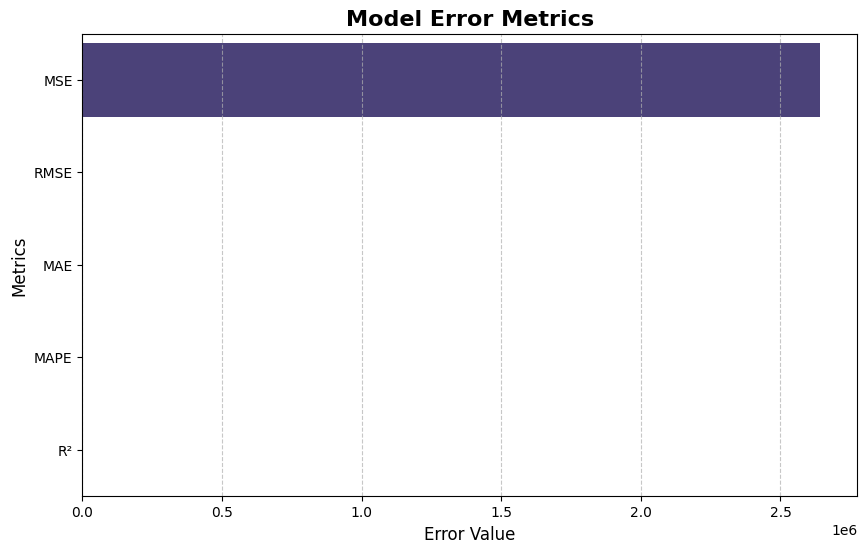

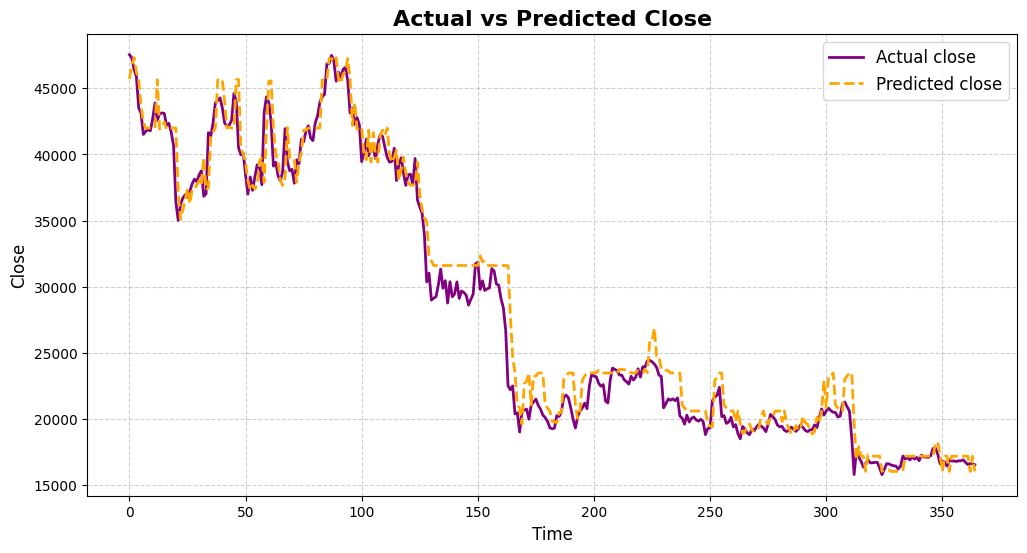

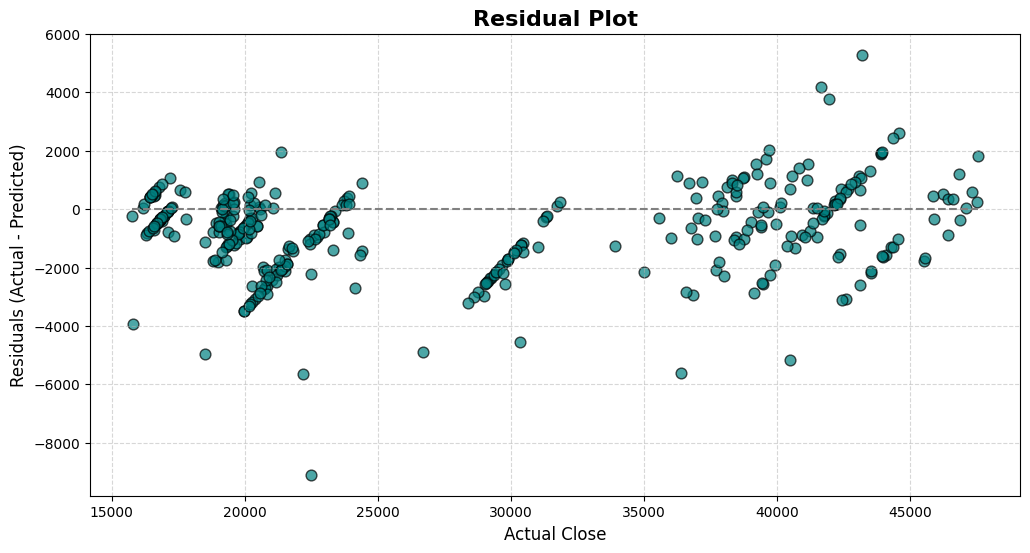

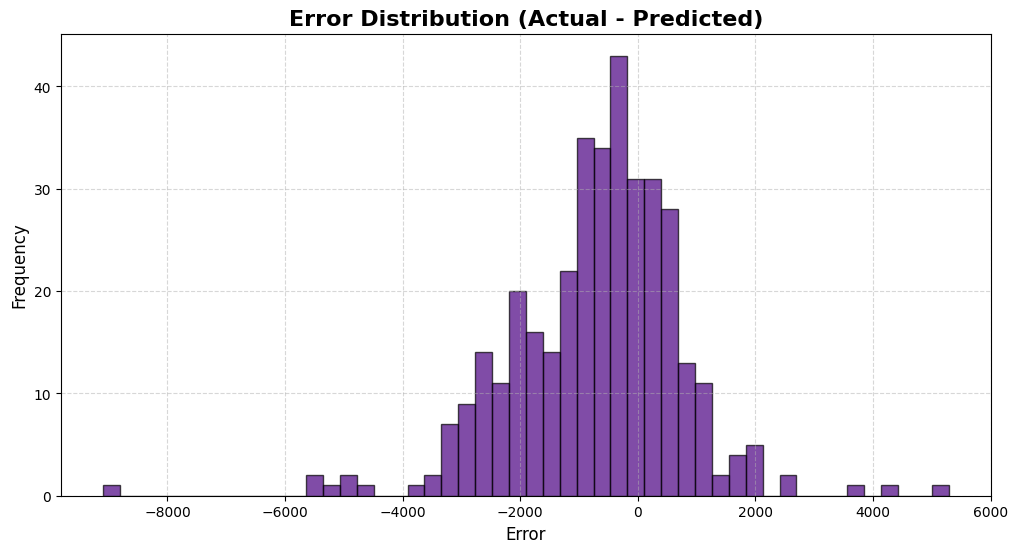

In [2]:
# Output the metrics
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}')
print(f'R² Score: {r2:.4f}')

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization of Metrics (Bar Chart)
metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R²': r2}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.values()), y=list(metrics.keys()), palette='viridis')
plt.title('Model Error Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Error Value', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualization: Actual vs Predicted (Line Plot)
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual close', color='purple', linewidth=2)
plt.plot(y_test_pred_original, label='Predicted close', color='orange', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Close', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Plot
residuals = y_test_original - y_test_pred_original
plt.figure(figsize=(12, 6))
plt.scatter(y_test_original, residuals, color='teal', edgecolor='black', alpha=0.7, s=60)
plt.hlines(y=0, xmin=y_test_original.min(), xmax=y_test_original.max(), color='gray', linestyle='--', linewidth=1.5)
plt.title('Residual Plot', fontsize=16, fontweight='bold')
plt.xlabel('Actual Close', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Error Distribution (Histogram)
errors = y_test_original - y_test_pred_original
plt.figure(figsize=(12, 6))
plt.hist(errors, bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.title('Error Distribution (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()